#### All Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import matrix
import matplotlib.gridspec as gridspec
from scipy.fft import fft, ifft
from scipy.ndimage import gaussian_filter1d,convolve1d
from dataclasses import dataclass
from typing import Tuple, Dict
import pywt
from scipy.signal import butter, filtfilt, chirp, stft
import time
import numba as nb
from scipy import signal
import os
import tempfile
import random
from collections import Counter
from scipy.stats import norm

import shap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist,squareform,cdist
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize

sys.path.append('/data/sswar_files/')
from PRJ_SPEC_MASTER.src.utils.spectograms_lib import *
from PRJ_SPEC_MASTER.src.utils.data_preparations import *
from PRJ_SPEC_MASTER.src.utils.noise_lib import *
from PRJ_GIS_QA.src.mowpt_dwt_cwt.synth_geophysical_waveforms import *
from PRJ_GIS_QA.src.utils.gisqa_compute_updated import *
from PRJ_GIS_QA.src.utils.plotting import *
from PRJ_GIS_QA.src.utils.helper import *

fig_save_path = '/data/sswar_files/PRJ_GIS_QA/figs/forpaper/all_results_figures/synth_geophysical_signals_application'

/home/sswar/.local/lib/python3.10/site-packages/porespy/filters/_lt_methods.py:21: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  strel = {2: {'min': disk(1), 'max': square(3)}, 3: {'min': ball(1), 'max': cube(3)}}
/home/sswar/.local/lib/python3.10/site-packages/porespy/filters/_lt_methods.py:21: FutureWarning: `cube` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  strel = {2: {'min': disk(1), 'max': square(3)}, 3: {'min': ball(1), 'max': cube(3)}}
/home/sswar/.local/lib/python3.10/site-packages/porespy/metrics/_funcs.py:65: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  strel = {2: {"min": disk(1), "max": square(3)}, 3: {"min": ball(1), "max": cube(3)}}
/home/sswar/.local/lib/python3.10/site-packages/pores

#### Utils

In [2]:
def _perform_hierarchical_clustering(data, method='ward', metric='euclidean', plot_dendrogram=True, color_threshold=None, figsize=(10, 6), savefig=False, savepath=None,VI=None):
    #distance_matrix = cdist(data, data, metric=metric) #pdist(data, metric=metric)
    if VI is not None:
        distance_matrix = pdist(data, metric=metric, VI=inv_cov_matrix)
    else:
        distance_matrix = pdist(data, metric=metric)
    linkage_matrix = linkage(distance_matrix, method=method, optimal_ordering=True)

    if plot_dendrogram:
        plt.figure(figsize=figsize)
        dendro = dendrogram(linkage_matrix, color_threshold=color_threshold, no_labels=True)            
        plt.title(f'Hierarchical Clustering Dendrogram (method={method}, metric={metric})')
        plt.xlabel('Sample index')
        plt.ylabel('Distance')
        if savefig:
            plt.savefig(savepath, dpi=300)
        plt.show()
        return linkage_matrix, dendro

    return linkage_matrix

def _merge_clusters(linkage_matrix, num_clusters=None, distance_threshold=None):
    if num_clusters is not None:
        labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')
    elif distance_threshold is not None:
        labels = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')
    else:
        raise ValueError("You must provide either 'num_clusters' or 'distance_threshold'")
    return labels

def _compute_cwt(signal, fs, n_scales=80, omega0=5.0, norm='l2',vmin_percentile=0,vmax_percentile=100,f_min=0,f_max=10):
    """CWT with configurable L1/L2 norm."""
    n = len(signal)
    n_pad = int(2 ** np.ceil(np.log2(2 * n)))
    data_pad = np.zeros(n_pad)
    data_pad[:n] = signal
    data_fft = fft(data_pad)

    nyquist = fs / 2.0
    if f_max is None:
        f_max = nyquist * 0.95
    elif f_max > nyquist:
        print(f"Warning: Requested f_max ({f_max}Hz) exceeds the Nyquist limit ({nyquist}Hz). Capping f_max.")
        f_max = nyquist * 0.95
    

    #freqs = np.linspace(0.5, fs/2.0 * 0.95, n_scales)
    freqs = np.linspace(f_min, f_max, n_scales)
    scales = (omega0 * fs) / (2.0 * np.pi * freqs)
    output = np.zeros((len(scales), n), dtype=complex)

    for i, scale in enumerate(scales):
        x = np.arange(n_pad) - (n_pad - 1.0) / 2.0

        # Apply strict scaling norms
        if norm == 'l1':
            scale_factor = scale
        elif norm == 'l2':
            scale_factor = np.sqrt(scale)
        else:
            raise ValueError("Norm must be 'l1' or 'l2'")

        psi = (np.pi ** -0.25) * np.exp(1j * omega0 * x / scale) * np.exp(-0.5 * (x / scale) ** 2) / scale_factor
        psi_fft = fft(np.roll(psi, -(n_pad // 2)))
        output[i, :] = ifft(data_fft * np.conj(psi_fft))[:n]

    spectro = np.abs(output)
    vmax = np.percentile(spectro, vmax_percentile)  
    vmin = np.percentile(spectro, vmin_percentile)  

    spectro[spectro > vmax] = vmax
    spectro[spectro < vmin] = vmin

    return spectro, freqs


#### Load Data

In [3]:
spec_pointwise_metrics_df = pd.read_csv("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/spec2vec_synth_geophysical_signals.csv")
spec_pointwise_metrics_df['label_print'] = ["_".join(label_str.split('_')[:-1]) for label_str in spec_pointwise_metrics_df['label']]
spec_pointwise_metrics_df = spec_pointwise_metrics_df.drop(columns=['label'])

waveform_catalog = np.load("/data/sswar_files/PRJ_GIS_QA/data/forpaper_V0/synth_geophysical_signals_application/synth_geophysical_waveform_catalog.npy", allow_pickle=True).item()

In [4]:
sel_colums = ['svd_entropy_antropy', 'detrended_fluctuation_antropy', 'hjorth_complexity_antropy', 
              'weighted_permutation_entropy_ordpy', '25th_percentile','label']

col_theshold = 3.5
dist_threshold = 3.5
features = spec_pointwise_metrics_df.drop(columns=['label_print']).values

scaler = StandardScaler()
features= scaler.fit_transform(features)
features = normalize(features, norm='l2')
linkage_matrix = _perform_hierarchical_clustering(features, method='ward',metric='euclidean',
                                                plot_dendrogram=False,color_threshold=col_theshold, savepath=None)
hir_labels = _merge_clusters(linkage_matrix, distance_threshold=dist_threshold)
print('Total Labels: ', len(hir_labels))
print(Counter(hir_labels))

cluster_label_map = pd.DataFrame({'labels':hir_labels, 'waveform_type':spec_pointwise_metrics_df['label_print'].tolist()})
cluster_conf_matrx = pd.crosstab(cluster_label_map['waveform_type'], cluster_label_map['labels'])
unique_classes = cluster_conf_matrx.index.tolist()
print(unique_classes)

features_names_to_print = ['SVD Entropy','Detrended Fluctuation', 'Hjorth Complexity', 'Weighted Perm. Entropy', '25th %tile']
short_classes = ['HE', 'IE', 'SE', 'SWD', 'TpEQ', 'VT']
legend_classes = ['Hybrid Eruption (HE)', 'Impulsive Earthquake (IE)', 'Strombolian Explosion (SE)', 
                    'Surface Wave Dispersion (SWD)', 'Tphase Earthquake (TpEQ)', 'Volcanic Tornillo (VT)']

Total Labels:  150
Counter({np.int32(2): 31, np.int32(6): 25, np.int32(4): 25, np.int32(5): 25, np.int32(3): 25, np.int32(1): 19})
['hybrid_eruption', 'impulsive_earthquake', 'strombolian_explosion', 'surface_wave_dispersion', 't_phase_earthquake', 'volcanic_tornillo']


#### FIGURES MAIN: Model Performance

In [9]:
def plot_nature_master_summary(df, label_col, features_to_plot, cm, unique_classes, filter_labels, spectro_dict, short_classes=None, features_names_to_print=None,
                                signal_plot_idx=0, legend_classes=None, savepath=None):

    unique_classes_print = legend_classes or unique_classes
    print_map = dict(zip(unique_classes, unique_classes_print))

    # ==========================================
    # 1. PUBLICATION AESTHETICS SETUP
    # ==========================================
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.linewidth': 0.8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'axes.labelsize': 10
    })

    # Colorblind-friendly Okabe-Ito Palette
    okabe_ito = ["#88bf9c", "#B72818","#FFB11C","#4B75FF","#480058","#CC79A7"]
    palette = {cls: okabe_ito[i % len(okabe_ito)] for i, cls in enumerate(unique_classes)}

    
    # Use short classes for the CM if provided, else use the wrapped full names
    cm_labels = short_classes

    # ==========================================
    # 2. MAIN GRID LAYOUT
    # ==========================================
    fig = plt.figure(figsize=(16, 9))
    
    # Divide the figure: 30% left, 70% right. Reduced wspace to limit whitespace
    gs_main = gridspec.GridSpec(1, 2, width_ratios=[0.3, 0.7], wspace=0.1)
    
    # Left column: 2 rows (CM top, Boxplot bottom). Reduced hspace
    gs_left = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[0], hspace=0.45)
    
    # Right column: 2 rows, 3 columns (for up to 6 classes). Reduced hspace/wspace
    gs_right = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs_main[1], wspace=0.08, hspace=0.15)


    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c], 
                markersize=9, label=print_map[c]) for c in unique_classes]
    
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.07),
               ncol=len(unique_classes)/2, frameon=True, fontsize=10)

    # ==========================================
    # 3. LEFT COLUMN: CONFUSION MATRIX
    # ==========================================
    ax_cm = fig.add_subplot(gs_left[0])
    
    # Plot heatmap (Greys to keep fill neutral)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=ax_cm, 
                xticklabels=np.arange(1,len(unique_classes)+1), yticklabels=cm_labels,
                annot_kws={"size": 10, "fontweight": "bold"})
    
    ax_cm.set_title("A. Model Confusion Matrix", fontsize=12, fontweight='bold', pad=15, loc='left')
    ax_cm.set_xlabel("Predicted Label", fontweight='bold',labelpad=10)
    ax_cm.set_ylabel("True Label", fontweight='bold',labelpad=10)
    
    # Rotate X-labels and color coordinate ALL labels to match the classes
    ax_cm.set_xticklabels(ax_cm.get_xticklabels(), ha='center') # rotation=45, ha='right'
    
    for i, t in enumerate(ax_cm.get_xticklabels()):
        #t.set_color(palette[unique_classes[i]])
        t.set_fontweight('bold')
    for i, t in enumerate(ax_cm.get_yticklabels()):
        t.set_color(palette[unique_classes[i]])
        t.set_fontweight('bold')

    # ==========================================
    # 4. LEFT COLUMN: FEATURE BOXPLOTS
    # ==========================================
    ax_box = fig.add_subplot(gs_left[1])
    
    # Standardize the data so different features can share the same Y-axis
    df_scaled = df.copy()
    numeric_cols = [c for c in features_to_plot if c in df.columns]
    df_scaled[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])
    
    # Melt for Seaborn
    melted_df = df_scaled.melt(id_vars=[label_col], value_vars=numeric_cols, 
                               var_name='Feature_Name', value_name='Value')
    
    sns.boxplot(data=melted_df, x='Feature_Name', y='Value', hue=label_col, 
                hue_order=unique_classes, palette=palette, showfliers=False, ax=ax_box, 
                linewidth=0.8, boxprops=dict(alpha=0.8))
    num_features = len(numeric_cols)
    for i in range(num_features - 1):
        ax_box.axvline(x=i + 0.5, color='lightgray', linestyle='-', linewidth=0.8, alpha=0.6, zorder=0)
    
    ax_box.set_title("B. Standardized Feature Distributions", fontsize=12, fontweight='bold', pad=10, loc='left')
    ax_box.set_xlabel("")
    ax_box.set_ylabel("")
    
    # Remove Y-axis ticks/labels as requested, keep X-axis
    ax_box.set_yticks([])
    ax_box.spines['left'].set_visible(False)
    ax_box.spines['right'].set_visible(False)
    ax_box.spines['top'].set_visible(False)
    
    # Use custom labels if provided, else auto-format
    if features_names_to_print is not None:
        short_feat_names = features_names_to_print
    else:
        short_feat_names = [f.replace('_', '\n') for f in numeric_cols]
        
    ax_box.set_xticklabels(short_feat_names, rotation=15, ha='right', fontsize=8)
    
    # Clean up the legend
    if ax_box.legend_ is not None:
        ax_box.legend_.remove() # We will rely on colors; CM and titles already explain classes

    # ==========================================
    # 5. RIGHT COLUMN: TIME SERIES & SPECTROGRAMS
    # ==========================================
    for i, class_name in enumerate(unique_classes):
        row = i // 3
        col = i % 3
        
        # Inner GridSpec inside each of the 6 cells: 30% TS, 70% CWT
        gs_cell = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_right[row, col], 
                                                   height_ratios=[0.4, 0.6], hspace=0.0)
        
        ax_ts = fig.add_subplot(gs_cell[0])
        ax_cwt = fig.add_subplot(gs_cell[1])
        
        # --- TIME SERIES (Top 30%) ---
        signal = spectro_dict[class_name][signal_plot_idx][1]
        signal_ts = spectro_dict[class_name][signal_plot_idx][0]
        signal_ts_mask = (signal_ts>=20) & (signal_ts<=50)
        cwt, _ = _compute_cwt(signal, fs=100.0, n_scales=32, norm='l2', vmin_percentile=0.5,vmax_percentile=99.5, f_min=0, f_max=20)

            
        # Plot Time Series with the exact class color
        ax_ts.plot(signal, color=palette[class_name], linewidth=0.5)
        #ax_ts.set_xlim([0, len(signal)])
        ax_ts.axis('off') # Remove all axes, ticks, spines
        ax_ts.margins(x=0, y=0) # Remove whitespace
        
        if i == 0:
            # Shifted Y coordinate to prevent overlap with the class title
            ax_ts.text(0, 1.15, "C. Physical Ground Truth (Time Series & CWT)", 
                       transform=ax_ts.transAxes, fontsize=12, fontweight='bold', color='black')

        # --- SPECTROGRAM (Bottom 70%) ---
        try:
            cwt_mag = np.abs(cwt)
            # Using 'magma' or 'viridis' is standard for Nature CWT representations
            ax_cwt.imshow(cwt_mag, aspect='auto', origin='lower', cmap='inferno')
            if i==0:
                ax_cwt.set_xlabel("Time", fontweight='bold', fontsize=9)
                ax_cwt.set_ylabel("Frequency", fontweight='bold', fontsize=9)
        except Exception as e:
            ax_cwt.text(0.5, 0.5, 'CWT Data Missing', ha='center', va='center', color='gray')
            
        ax_cwt.set_xticks([])
        ax_cwt.set_yticks([])
        ax_cwt.margins(x=0, y=0)
        sns.despine(ax=ax_cwt, left=True, bottom=True, right=True, top=True)

        # Place the short class label in the top right corner of the CWT
        short_name = cm_labels[i]
        ax_cwt.text(0.97, 0.95, short_name, transform=ax_cwt.transAxes,
                    color=palette[class_name], fontsize=10, fontweight='bold',
                    ha='right', va='top', zorder=10,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.2'))

    # ------------------------------------------
    # Clean up empty cells and add metrics
    # ------------------------------------------
    for i in range(len(unique_classes), 6):
        row = i // 3
        col = i % 3
        ax_empty = fig.add_subplot(gs_right[row, col])
        ax_empty.axis('off')
        
        # Inject the performance metrics text into the 6th cell (index 5)
        if i == 5:
            metrics_text = (
                "Accuracy from test set: 74.2%\n"
                "Balanced Accuracy: 80.23%\n"
                "Macro F1-Score: 0.7657"
            )
            ax_empty.text(0.5, 0.5, metrics_text, ha='center', va='center', 
                          fontsize=11, fontweight='bold', color='#333333',
                          bbox=dict(facecolor='#f7f7f7', alpha=0.9, edgecolor='none', boxstyle='round,pad=1'))

    # ==========================================
    # 6. FINALIZE AND EXPORT
    # ==========================================
    # Use tighter bounding box logic
    plt.tight_layout()
    plt.subplots_adjust(top=0.94, bottom=0.06, left=0.04, right=0.98)
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', format='png')
        print(f"Saved publication figure to {savepath}")
        
    plt.show()


/tmp/ipykernel_481185/1831237129.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(short_feat_names, rotation=15, ha='right', fontsize=8)
/tmp/ipykernel_481185/1831237129.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved publication figure to /data/sswar_files/PRJ_GIS_QA/figs/forpaper_V1/all_results_figures/synth_geophysical_signals_application/Synth_Geophysical_ModelPerf.png


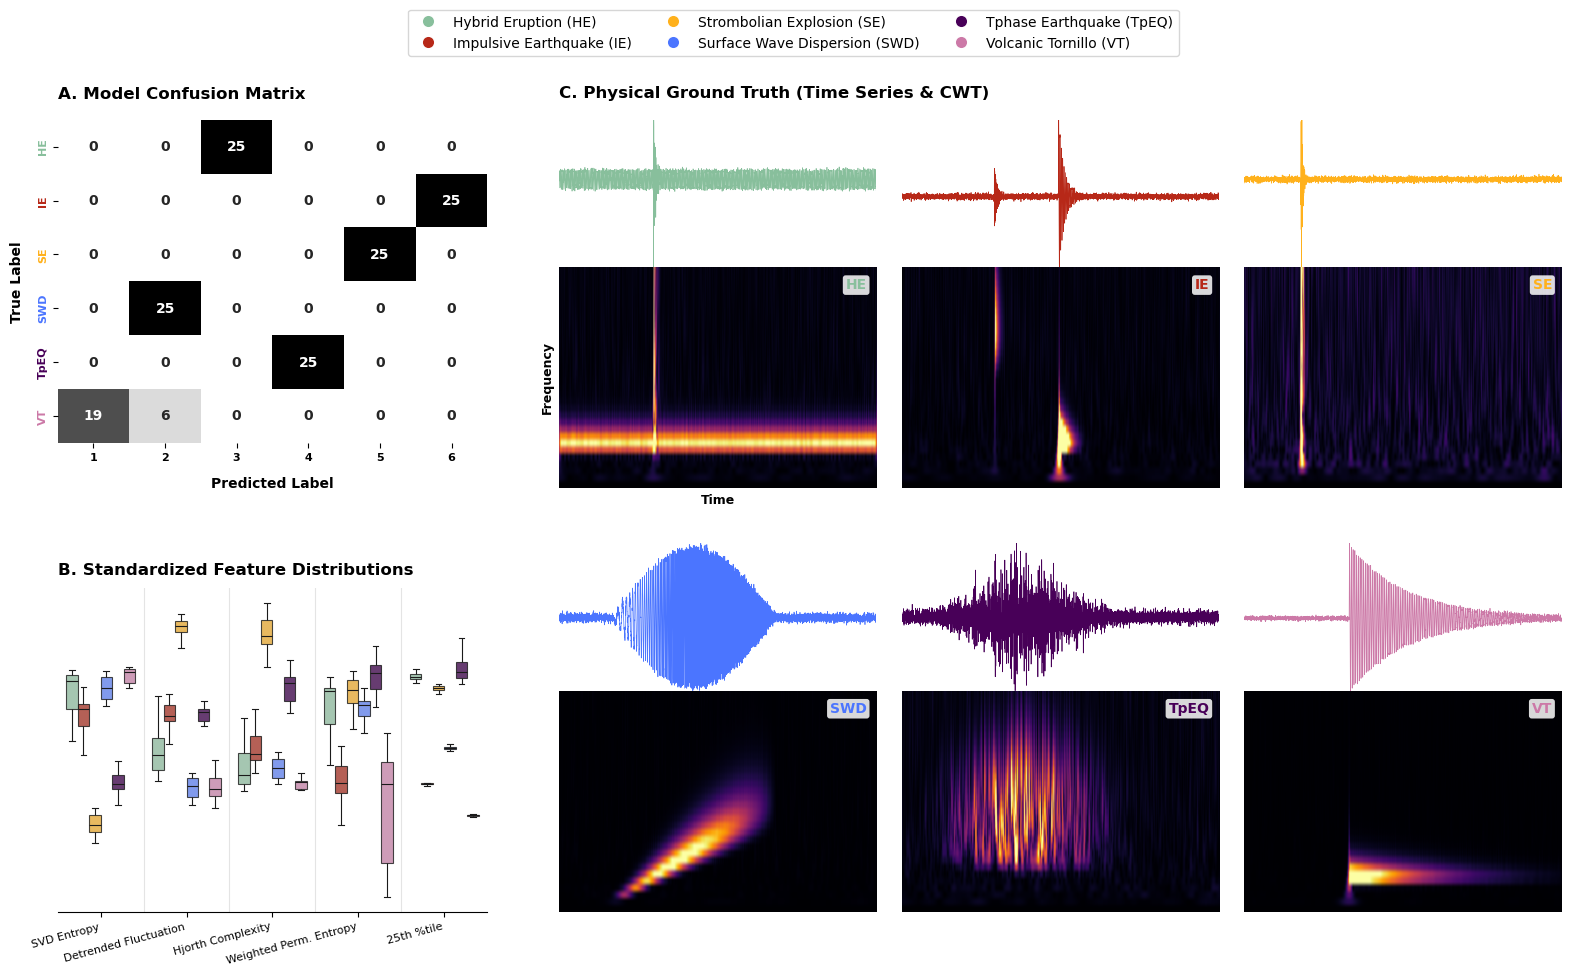

In [10]:
plot_nature_master_summary(
    df=spec_pointwise_metrics_df, 
    label_col='label_print',
    features_to_plot=sel_colums,
    cm=cluster_conf_matrx,
    unique_classes=unique_classes,
    filter_labels=unique_classes, 
    spectro_dict=waveform_catalog,
    short_classes=short_classes,
    features_names_to_print=features_names_to_print,
    signal_plot_idx=2,
    legend_classes=legend_classes,
    savepath="/data/sswar_files/PRJ_GIS_QA/figs/forpaper_V1/all_results_figures/synth_geophysical_signals_application/Synth_Geophysical_ModelPerf.png",
)